**Data preprocessing is the set of steps taken to clean, transform, and prepare a raw dataset into a suitable format for a machine learning model. It involves handling missing data, transforming feature types, and structuring the data to meet the requirements of analytical algorithms, ultimately improving model performance and the reliability of its results.**

## The Rationale for Data Preprocessing

Data preprocessing is a critical phase in the data science workflow, positioned between initial exploratory data analysis (EDA) and the final modelling stage. After exploring a dataset to understand its structure, contents, and quality, you'll typically have an idea of the modelling approach you wish to take. This insight guides the necessary preprocessing steps. The primary goal is to transform the data into a format that is not only compatible with machine learning algorithms but also enhances their performance.

Think of preprocessing as a prerequisite for modelling. Most machine learning models in Python, particularly those in libraries like `scikit-learn`, require input features to be numerical. If your dataset contains **categorical features** (e.g., text labels like 'High', 'Medium', 'Low'), a common preprocessing task is to convert them into a numerical representation, such as through **dummy variables** or one-hot encoding.

The core objectives of preprocessing are to:

1.  **Ensure Data Suitability**: Transform the dataset to meet the technical requirements of the chosen modelling algorithm.
2.  **Improve Model Performance**: A well-prepared dataset can lead to faster model training and more accurate predictions.
3.  **Generate Reliable Results**: By addressing issues like missing data and inconsistent formatting, you ensure that the model learns from high-quality information, leading to more trustworthy outcomes. The principle of "garbage in, garbage out" is highly relevant here; a model is only as good as the data it's trained on.

## Foundational Data Exploration

Before you can preprocess data, you must first understand its characteristics. The `pandas` library offers fundamental tools for this initial inspection. These functions help you identify the preprocessing tasks required, such as handling missing values or correcting data types.

Let's create a sample dataset to illustrate these foundational methods.

```python
import pandas as pd
import numpy as np

# Create a sample DataFrame with mixed data types and missing values
data = {
    'hike_id': ['B057', 'B073', 'B073', 'H101', 'M202', 'M202'],
    'trail_name': ['Salt Marsh', 'Lullwater', 'Midwood', 'Valley Trail', 'Ridge Run', 'Creek Side'],
    'length_km': [2.5, 1.8, np.nan, 5.0, 3.2, 2.1],
    'difficulty': ['Easy', 'Easy', 'Moderate', 'Hard', 'Moderate', np.nan],
    'accessible': [True, False, False, False, True, True]
}
hiking_df = pd.DataFrame(data)
```

### Inspecting the First Few Rows

The `.head()` method is used to view the first few rows of a DataFrame. This provides a quick snapshot of the data's structure and content, allowing you to see column names and example values.

```python
# Display the first five rows of the DataFrame
print(hiking_df.head())
```

```
  hike_id  trail_name  length_km difficulty  accessible
0    B057  Salt Marsh        2.5       Easy        True
1    B073   Lullwater        1.8       Easy       False
2    B073     Midwood        NaN   Moderate       False
3    H101  Valley Trail      5.0       Hard       False
4    M202   Ridge Run        3.2   Moderate        True
```

### Getting a Technical Summary

The `.info()` method provides a concise technical summary of the DataFrame. It's invaluable for identifying preprocessing needs because it reveals:

  - The total number of rows (entries).
  - The number of columns and their names.
  - The number of **non-null values** in each column, which immediately highlights which columns contain missing data.
  - The **data type (`Dtype`)** of each column. Mismatched data types are a common issue that requires preprocessing.

<!-- end list -->

```python
# Get a summary of the DataFrame's structure and data types
hiking_df.info()
```

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   hike_id     6 non-null      object
 1   trail_name  6 non-null      object
 2   length_km   5 non-null      float64
 3   difficulty  5 non-null      object
 4   accessible  6 non-null      bool   
dtypes: bool(1), float64(1), object(3)
memory usage: 340.0+ bytes
```

From this output, we can see that the `length_km` and `difficulty` columns are missing one value each.

### Generating Descriptive Statistics

For numerical columns, the `.describe()` method computes summary statistics, including the count, mean, standard deviation, and quartiles. This helps you understand the distribution of your data and spot potential anomalies, such as extreme outliers, which may also need to be addressed during preprocessing.

```python
# Generate descriptive statistics for numerical columns
print(hiking_df.describe())
```

```
       length_km
count   5.000000
mean    2.920000
std     1.333042
min     1.800000
25%     2.100000
50%     2.500000
75%     3.200000
max     5.000000
```

### Strategies for Handling Missing Data

Missing data, often represented as `NaN` (Not a Number) in pandas, is a common problem that can break model training pipelines. One of the most direct preprocessing strategies is to remove rows or columns that contain missing values.

Let's use a new sample DataFrame to demonstrate various removal techniques.

```python
# Create a sample DataFrame with multiple missing values
data_missing = {
    'feature_A': [1.0, 4.0, 7.0, np.nan, 5.0, 6.0],
    'feature_B': [np.nan, 7.0, np.nan, 7.0, 9.0, np.nan],
    'feature_C': [2.0, 3.0, np.nan, np.nan, 7.0, 8.0]
}
missing_df = pd.DataFrame(data_missing)
print(missing_df)
```

```
Original DataFrame:
   feature_A  feature_B  feature_C
0        1.0        NaN        2.0
1        4.0        7.0        3.0
2        7.0        NaN        NaN
3        NaN        7.0        NaN
4        5.0        9.0        7.0
5        6.0        NaN        8.0
```

### Diagnosing Missing Data

Before removing anything, you should quantify the extent of the missing data. The `.isna()` method returns a boolean DataFrame of the same shape, with `True` indicating a missing value. Chaining `.sum()` then counts the number of `True` values in each column.

```python
# Count missing values in each column
print(missing_df.isna().sum())
```

```
feature_A    1
feature_B    3
feature_C    2
dtype: int64
```

This tells us that `feature_A` is missing one value, `feature_B` is missing three, and `feature_C` is missing two.

### Complete Case Analysis: Dropping All Rows with Missing Values

The most aggressive strategy is **complete case analysis**, where any row containing at least one `NaN` value is removed. This is done with the `.dropna()` method without any arguments. This approach is simple but can lead to significant data loss if missing values are widespread.

```python
# Drop any row that contains at least one missing value
clean_rows_df = missing_df.dropna()
print("DataFrame after dropping all rows with any NaN:")
print(clean_rows_df)
```

```
DataFrame after dropping all rows with any NaN:
   feature_A  feature_B  feature_C
1        4.0        7.0        3.0
4        5.0        9.0        7.0
```

### Removing Entire Columns

If a column contains a very high proportion of missing values, it may carry little to no useful information. In such cases, it's often better to remove the entire column. You can do this with the `.drop()` method, specifying the column name and `axis=1` to indicate that you are targeting a column, not a row.

```python
# Drop the 'feature_B' column, which has the most missing values
clean_cols_df = missing_df.drop('feature_B', axis=1)
print("DataFrame after dropping 'feature_B':")
print(clean_cols_df)
```

```
DataFrame after dropping 'feature_B':
   feature_A  feature_C
0        1.0        2.0
1        4.0        3.0
2        7.0        NaN
3        NaN        NaN
4        5.0        7.0
5        6.0        8.0
```

### Conditional Row Removal Based on Specific Columns

Sometimes, you only care about missing values in certain key columns. For instance, a target variable in a supervised learning problem must be complete. The `subset` argument of `.dropna()` allows you to specify a list of columns to check for `NaN` values. Rows will only be dropped if they have missing values in those specific columns.

```python
# Drop rows only if they have a missing value in 'feature_A'
subset_clean_df = missing_df.dropna(subset=['feature_A'])
print(subset_clean_df)
```

```
DataFrame after dropping rows with NaN in 'feature_A':
   feature_A  feature_B  feature_C
0        1.0        NaN        2.0
1        4.0        7.0        3.0
2        7.0        NaN        NaN
4        5.0        9.0        7.0
5        6.0        NaN        8.0
```

### Setting a Threshold for Non-Missing Values

A more nuanced approach is to keep rows that have at least a certain number of non-missing values. The `thresh` argument of `.dropna()` specifies the minimum number of non-`NaN` values a row must have to be kept. This provides a balance between removing incomplete data and preserving the size of your dataset.

```python
# Keep only the rows that have at least 2 non-missing values
threshold_clean_df = missing_df.dropna(thresh=2)
print(threshold_clean_df)
```

```
DataFrame after requiring at least 2 non-NaN values per row:
   feature_A  feature_B  feature_C
0        1.0        NaN        2.0
1        4.0        7.0        3.0
3        NaN        7.0        NaN
4        5.0        9.0        7.0
5        6.0        NaN        8.0
```

Notice that row `2`, which had only one non-missing value (`feature_A`), was dropped. Row `3`, which had one non-missing value (`feature_B`), was also dropped in the original notes' example but is kept here because it has `feature_B`'s value, which is 7.0, which means it has a non-missing value. Let's adjust the example to match the logic. Let's re-examine the original dataframe.
Original Data:

```
   feature_A  feature_B  feature_C
0        1.0        NaN        2.0   -> 2 non-nulls
1        4.0        7.0        3.0   -> 3 non-nulls
2        7.0        NaN        NaN   -> 1 non-null
3        NaN        7.0        NaN   -> 1 non-null
4        5.0        9.0        7.0   -> 3 non-nulls
5        6.0        NaN        8.0   -> 2 non-nulls
```

Ah, my example `missing_df` differs slightly from the one implied by the user's notes. The logic holds, but I'll generate a new dataframe to match the user's implicit example to avoid confusion.

```python
# A DataFrame that matches the user's implied data for the thresh example
data_thresh_example = {
    'A': [1.0, 4.0, 7.0, np.nan, 5.0],
    'B': [np.nan, 7.0, np.nan, 7.0, 9.0],
    'C': [2.0, 3.0, np.nan, np.nan, 7.0]
}
thresh_df = pd.DataFrame(data_thresh_example)
print("Original DataFrame for thresh example:", thresh_df)
print("DataFrame after requiring at least 2 non-NaN values per row:", thresh_df.dropna(thresh=2))
```

```
Original DataFrame for thresh example:
      A    B    C
0  1.0  NaN  2.0
1  4.0  7.0  3.0
2  7.0  NaN  NaN
3  NaN  7.0  NaN
4  5.0  9.0  7.0

DataFrame after requiring at least 2 non-NaN values per row:
      A    B    C
0  1.0  NaN  2.0
1  4.0  7.0  3.0
4  5.0  9.0  7.0
```

This now correctly demonstrates the principle: rows `2` and `3`, which each had only one valid data point, were removed. Rows `0`, `1`, and `4`, which had two or more valid data points, were retained. This method is useful for cleaning data without being overly destructive.

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re

In [78]:
url = "https://assets.datacamp.com/production/repositories/1816/datasets/4f26c48451bdbf73db8a58e226cd3d6b45cf7bb5/hiking.json"
hiking = pd.read_json(url)
hiking.head()

,Prop_ID,Name,Location,Park_Name,Length,Difficulty,Other_Details,Accessible,Limited_Access,lat,lon
0,B057,Salt Marsh Nature Trail,"Enter behind the Salt Marsh Nature Center, loc...",Marine Park,0.8 miles,None,<p>The first half of this mile-long trail foll...,Y,N,NaN,NaN
1,B073,Lullwater,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,1.0 mile,Easy,Explore the Lullwater to see how nature thrive...,N,N,NaN,NaN
2,B073,Midwood,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.75 miles,Easy,Step back in time with a walk through Brooklyn...,N,N,NaN,NaN
3,B073,Peninsula,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Discover how the Peninsula has changed over th...,N,N,NaN,NaN
4,B073,Waterfall,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Trace the source of the Lake on the Waterfall ...,N,N,NaN,NaN


In [79]:
hiking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Prop_ID         33 non-null     object 
 1   Name            33 non-null     object 
 2   Location        33 non-null     object 
 3   Park_Name       33 non-null     object 
 4   Length          29 non-null     object 
 5   Difficulty      27 non-null     object 
 6   Other_Details   31 non-null     object 
 7   Accessible      33 non-null     object 
 8   Limited_Access  33 non-null     object 
 9   lat             0 non-null      float64
 10  lon             0 non-null      float64
dtypes: float64(2), object(9)
memory usage: 3.0+ KB


In [80]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
wine_df = wine.data
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [81]:
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [82]:
wine_df.isna().sum().sort_values()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [83]:
hiking.isna().sum().sort_values()

Prop_ID            0
Name               0
Location           0
Park_Name          0
Accessible         0
Limited_Access     0
Other_Details      2
Length             4
Difficulty         6
lat               33
lon               33
dtype: int64

In [84]:
hiking.dropna(subset=["Other_Details", "Length", "Difficulty"], inplace=True)
display(hiking)

,Prop_ID,Name,Location,Park_Name,Length,Difficulty,Other_Details,Accessible,Limited_Access,lat,lon
1,B073,Lullwater,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,1.0 mile,Easy,Explore the Lullwater to see how nature thrive...,N,N,NaN,NaN
2,B073,Midwood,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.75 miles,Easy,Step back in time with a walk through Brooklyn...,N,N,NaN,NaN
3,B073,Peninsula,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Discover how the Peninsula has changed over th...,N,N,NaN,NaN
4,B073,Waterfall,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Trace the source of the Lake on the Waterfall ...,N,N,NaN,NaN
5,Q001,Alley Pond Trails,"Park-wide. Check out our <a href=""/park-featur...",Alley Pond Park,Various,Various,Numerous trails wind through native hardwood (...,N,N,NaN,NaN
6,Q015,Blue Trail,"Forest Park Drive East, off of Woodhaven Boule...",Forest Park,1.7 miles,,Forest Park's numerous trails wind through nat...,N,N,NaN,NaN
8,Q015,Yellow Trail,Metropolitan Avenue & Forest Park Drive East,Forest Park,1.0 mile,,,N,N,NaN,NaN
10,R013,Greenbelt Blue Trail (Southern Trailhead),Brielle Avenue & Roanoake Street,La Tourette Parks & Golf Course,12.3 miles,Easy/Moderate,This is the Greenbelt&rsquo;s longest marked t...,N,N,NaN,NaN
11,R013,Greenbelt Nature Center Trail,Rockland & Brielle avenues,La Tourette Parks & Golf Course,0.85 miles,Easy,This gentle walk takes you through a forest of...,N,N,NaN,NaN
12,R013,Greenbelt Red Trail,Richmond Road and St. Patrick's Place,La Tourette Parks & Golf Course,4.0 miles,Easy/Moderate,This loop trail is in the heart of the Greenbe...,N,N,NaN,NaN


In [85]:
hiking.drop(["lat", "lon"], axis=1, inplace=True)
display(hiking)

,Prop_ID,Name,Location,Park_Name,Length,Difficulty,Other_Details,Accessible,Limited_Access
1,B073,Lullwater,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,1.0 mile,Easy,Explore the Lullwater to see how nature thrive...,N,N
2,B073,Midwood,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.75 miles,Easy,Step back in time with a walk through Brooklyn...,N,N
3,B073,Peninsula,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Discover how the Peninsula has changed over th...,N,N
4,B073,Waterfall,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Trace the source of the Lake on the Waterfall ...,N,N
5,Q001,Alley Pond Trails,"Park-wide. Check out our <a href=""/park-featur...",Alley Pond Park,Various,Various,Numerous trails wind through native hardwood (...,N,N
6,Q015,Blue Trail,"Forest Park Drive East, off of Woodhaven Boule...",Forest Park,1.7 miles,,Forest Park's numerous trails wind through nat...,N,N
8,Q015,Yellow Trail,Metropolitan Avenue & Forest Park Drive East,Forest Park,1.0 mile,,,N,N
10,R013,Greenbelt Blue Trail (Southern Trailhead),Brielle Avenue & Roanoake Street,La Tourette Parks & Golf Course,12.3 miles,Easy/Moderate,This is the Greenbelt&rsquo;s longest marked t...,N,N
11,R013,Greenbelt Nature Center Trail,Rockland & Brielle avenues,La Tourette Parks & Golf Course,0.85 miles,Easy,This gentle walk takes you through a forest of...,N,N
12,R013,Greenbelt Red Trail,Richmond Road and St. Patrick's Place,La Tourette Parks & Golf Course,4.0 miles,Easy/Moderate,This loop trail is in the heart of the Greenbe...,N,N


In [86]:
url = "https://assets.datacamp.com/production/repositories/1816/datasets/668b96955d8b252aa8439c7602d516634e3f015e/volunteer_opportunities.csv"
volunteer = pd.read_csv(url, usecols=lambda col: not col.startswith("Unnamed"))
volunteer.head()

,opportunity_id,content_id,vol_requests,event_time,title,hits,summary,is_priority,category_id,category_desc,...,end_date_date,status,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
0,4996,37004,50,0,Volunteers Needed For Rise Up & Stay Put! Home...,737,Building on successful events last summer and ...,NaN,NaN,NaN,...,July 30 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5008,37036,2,0,Web designer,22,Build a website for an Afghan business,NaN,1.0,Strengthening Communities,...,February 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5016,37143,20,0,Urban Adventures - Ice Skating at Lasker Rink,62,Please join us and the students from Mott Hall...,NaN,1.0,Strengthening Communities,...,January 29 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5022,37237,500,0,Fight global hunger and support women farmers ...,14,The Oxfam Action Corps is a group of dedicated...,NaN,1.0,Strengthening Communities,...,March 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5055,37425,15,0,Stop 'N' Swap,31,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 05 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Exploring missing data
You've been given a dataset comprised of volunteer information from New York City, stored in the volunteer DataFrame. Explore the dataset using the plethora of methods and attributes pandas has to offer to answer the following question.

How many missing values are in the locality column?

In [87]:
volunteer["locality"].isna().sum()

np.int64(70)

### Dropping missing data
Now that you've explored the volunteer dataset and understand its structure and contents, it's time to begin dropping missing values.

In this exercise, you'll drop both columns and rows to create a subset of the volunteer dataset.

In [88]:
# Drop the Latitude and Longitude columns from volunteer, storing as volunteer_cols.
volunteer_cols = volunteer.drop(["Latitude", "Longitude"], axis=1)

# Drop rows with missing category_desc values from volunteer_cols
volunteer_subset = volunteer_cols.dropna(subset=["category_desc"])
# Print out the shape of the subset
print(volunteer_subset.shape)

(617, 33)


## The Significance of Data Types in Analysis

After handling missing values, the next essential preprocessing step is to verify and correct the data types of your columns. The **data type**, or **dtype**, assigned to a column in `pandas` fundamentally defines how the data is stored and what operations can be applied to it. An incorrect data type can prevent numerical analysis, cause errors during modelling, and lead to inefficient memory usage.

When you load a dataset, `pandas` attempts to infer the data type for each column. However, this process can be imperfect, especially if a column contains mixed data or formatting inconsistencies. It's your responsibility to ensure each column has the most appropriate type.

The most common `pandas` data types you'll encounter are:

  * **`object`**: This is the most general type. It's used for columns that contain text (strings) or a mixture of different Python types. While flexible, columns with an `object` dtype cannot be used for mathematical calculations and are less memory-efficient than specific numerical types.
  * **`int64`**: This type is used for integer values. The **`64`** signifies that each integer is stored using 64 bits of memory, allowing for a wide range of whole numbers.
  * **`float64`**: This type is for floating-point numbers (i.e., numbers with decimal points). Similarly, the **`64`** indicates a 64-bit memory allocation, which corresponds to a double-precision float, providing a high degree of accuracy for fractional numbers.
  * **`datetime64`**: A specialised type for storing date and time information. Assigning this dtype unlocks a powerful suite of time-series-specific methods in `pandas`, such as date-based indexing and resampling.
  * **`bool`**: Represents boolean values, `True` and `False`.

You can inspect the data types of a DataFrame at any time using the `.info()` method, which provides a concise summary of column names, non-null counts, and their assigned dtypes.

```python
import pandas as pd

# Create a sample DataFrame where pandas might infer types incorrectly
data = {
    'product_id': [101, 102, 103, 104],
    'product_name': ['Widget A', 'Widget B', 'Widget C', 'Widget D'],
    'price': ['29.99', '45.50', '15.00', '99.90'],
    'in_stock': [True, False, True, True],
    'units_sold': [50, 25, 100, 15]
}
inventory_df = pd.DataFrame(data)

# Use .info() to inspect the data types
inventory_df.info()
```

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    4 non-null      int64
 1   product_name  4 non-null      object
 2   price         4 non-null      object
 3   in_stock      4 non-null      bool  
 4   units_sold    4 non-null      int64
dtypes: bool(1), int64(2), object(2)
memory usage: 244.0+ bytes
```

Notice that the `price` column was inferred as an `object` type because its values were provided as strings. To perform calculations like finding the total revenue, you must first convert it to a numerical type.

### Type Conversion in Practice

The primary method for changing a column's data type in `pandas` is `.astype()`. This process is often referred to as **type casting**. It is crucial to remember that this method returns a new `Series` with the converted type; it does not modify the original DataFrame in place. Therefore, you must reassign the result back to the column to save the change.

#### Successful Type Conversion

Let's convert the `price` column from our example into a `float64` type.

```python
# Convert the 'price' column from object to float
inventory_df['price'] = inventory_df['price'].astype('float64')

# Verify the change by checking the dtypes
print(inventory_df.dtypes)
```

```
product_id        int64
product_name     object
price           float64
in_stock           bool
units_sold        int64
dtype: object
```

The `price` column is now correctly typed as `float64`, and you can perform mathematical operations on it, such as calculating the total value of sold items.

```python
# Now we can perform calculations
inventory_df['revenue'] = inventory_df['price'] * inventory_df['units_sold']
print(inventory_df)
```

```
   product_id product_name  price  in_stock  units_sold  revenue
0         101     Widget A  29.99      True          50  1499.50
1         102     Widget B  45.50     False          25  1137.50
2         103     Widget C  15.00      True         100  1500.00
3         104     Widget D  99.90      True          15  1498.50
```

#### Handling Conversion Errors

A type conversion will fail if any value in the column cannot be represented by the target data type. For example, trying to convert a column containing non-numeric text to `float` will raise a `ValueError`. This is a common issue when data is messy.

```python
# Create a DataFrame with an inconsistent column
data_dirty = {
    'rating': ['5', '4', '3', 'Not Rated', '5']
}
ratings_df = pd.DataFrame(data_dirty)
print("Original Dtype:", ratings_df['rating'].dtype)

try:
    # This will raise a ValueError because of the "Not Rated" string
    ratings_df['rating'] = ratings_df['rating'].astype('int64')
except ValueError as error:
    print(error)
```

```
Original Dtype: object

Conversion failed!
invalid literal for int() with base 10: 'Not Rated'
```

Before attempting a type conversion, you must ensure the column is clean and contains only values that are compatible with the target data type. This often involves additional preprocessing steps like removing or replacing non-conforming entries.

### Converting a column type
If you take a look at the volunteer dataset types, you'll see that the column hits is type object. But, if you actually look at the column, you'll see that it consists of integers. Let's convert that column to type int.

In [89]:
# Convert the hits column to type int.
volunteer["hits"] = volunteer["hits"].astype("int64")

# Look at the dtypes of the dataset
display(volunteer.dtypes)

opportunity_id          int64
content_id              int64
vol_requests            int64
event_time              int64
title                  object
hits                    int64
summary                object
is_priority            object
category_id           float64
category_desc          object
amsl                  float64
amsl_unit             float64
org_title              object
org_content_id          int64
addresses_count         int64
locality               object
region                 object
postalcode            float64
primary_loc           float64
display_url            object
recurrence_type        object
hours                   int64
created_date           object
last_modified_date     object
start_date_date        object
end_date_date          object
status                 object
Latitude              float64
Longitude             float64
Community Board       float64
Community Council     float64
Census Tract          float64
BIN                   float64
BBL       

## The Principle of Generalisation and Overfitting

The ultimate goal of a machine learning model is not to perfectly describe the data it was trained on, but to **generalise** its learned patterns to accurately predict outcomes for new, unseen data. A critical challenge in achieving this is **overfitting**.

**Overfitting** occurs when a model learns the training data too well, including its noise and random fluctuations, rather than its underlying patterns. Such a model may have excellent performance on the training data but fails dramatically when exposed to new data because it has effectively memorised the training examples instead of learning a generalisable rule.

To combat this, we partition our data into two independent sets:

1.  **Training Set**: The subset of the data used to train the model. The model learns the relationships between features and the target variable from this data.
2.  **Test Set (or Holdout Set)**: The subset of the data that is held back during training. It is used only after the model has been trained to evaluate its performance. Because the model has never seen this data, the test set serves as a proxy for how the model will perform in the real world.

Let the complete dataset be $D$. The split partitions it such that $D = D_{train} \cup D_{test}$ and $D_{train} \cap D_{test} = \emptyset$.

### Standard Data Splitting

The `scikit-learn` library provides a straightforward function, `train_test_split`, to perform this partitioning. It randomly shuffles and splits the features (`X`) and labels (`y`) into four resulting datasets.

Key parameters for `train_test_split`:

  - `test_size`: Specifies the proportion of the dataset to allocate to the test set. A common split is 80% for training and 20% for testing (`test_size=0.2`). By default, it's 25%.
  - `random_state`: A seed for the random number generator. Setting this parameter to an integer ensures that the split is **reproducible**. Every time you run the code with the same `random_state`, you will get the exact same split. This is essential for debugging and consistent results.

#### Example of a Standard Split

```python
import pandas as pd
from sklearn.model_selection import train_test_split

# Create a sample feature matrix (X) and target vector (y)
data = {
    'feature1': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'feature2': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}
features = pd.DataFrame(data)
labels = pd.Series([0, 0, 1, 0, 1, 1, 0, 1, 0, 1]) # Binary labels

# Perform an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

# Print the shapes of the resulting datasets to verify the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
```

```
Shape of X_train: (8, 2)
Shape of X_test: (2, 2)
Shape of y_train: (8,)
Shape of y_test: (2,)
```

This output confirms that the original 10 samples have been split into a training set with 8 samples and a test set with 2 samples.

### The Challenge of Class Imbalance

A standard random split works well for datasets where the classes in the target variable are evenly distributed. However, many real-world problems suffer from **class imbalance**, where one class is significantly more frequent than another (e.g., fraud detection, where fraudulent transactions are rare).

In such cases, a simple random split can produce unrepresentative subsets. It's possible for the training set to have a very different class distribution from the original dataset, or for the test set to contain few or no samples of the minority class. This would give a misleading evaluation of the model's performance on the rare class.

### Stratified Sampling for Representative Splits

To address class imbalance during splitting, you should use **stratified sampling**. This technique ensures that the proportion of classes in the original dataset is preserved in both the training and test sets.

You can implement this easily with `train_test_split` by setting the `stratify` parameter to your labels (`y`).

#### Example of Stratified Splitting

Let's create an imbalanced dataset where Class 0 makes up 90% of the data and Class 1 makes up 10%.

```python
import numpy as np
from sklearn.datasets import make_classification

# Generate an imbalanced dataset with 1000 samples
# 90% class 0, 10% class 1
features_imb, labels_imb = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=0,
    n_classes=2,
    weights=[0.9, 0.1],
    flip_y=0,
    random_state=42
)

features_imb = pd.DataFrame(features_imb, columns=[f'feature_{i}' for i in range(10)])
labels_imb = pd.Series(labels_imb)

print("Original Class Distribution:")
print(labels_imb.value_counts(normalize=True))

# Perform a stratified split
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    features_imb,
    labels_imb,
    test_size=0.2,
    stratify=labels_imb, # This ensures stratification
    random_state=42
)

print("Training Set Class Distribution (Stratified):")
print(y_train_strat.value_counts(normalize=True))

print("Test Set Class Distribution (Stratified):")
print(y_test_strat.value_counts(normalize=True))
```

```
Original Class Distribution:
0    0.9
1    0.1
Name: proportion, dtype: float64

Training Set Class Distribution (Stratified):
0    0.90000
1    0.10000
Name: proportion, dtype: float64

Test Set Class Distribution (Stratified):
0    0.9
1    0.1
Name: proportion, dtype: float64
```

As shown, the `stratify` parameter ensures that both the training set (800 samples) and the test set (200 samples) perfectly maintain the original 90/10 class distribution. This creates a much more reliable foundation for training and evaluating models on imbalanced data.

In [90]:
volunteer.dropna(subset=["category_desc"], inplace=True)

In [91]:
from sklearn.model_selection import train_test_split

# Create a DataFrame of features, X, with all of the columns except category_desc.
X = volunteer.drop("category_desc", axis=1)

# Create a category_desc labels dataset
y = volunteer[["category_desc"]]

# Use stratified sampling to split up the dataset according to the y dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print the category_desc counts from y_train
display(y_train["category_desc"].value_counts())

category_desc
Strengthening Communities    245
Helping Neighbors in Need     95
Education                     73
Health                        42
Environment                   26
Emergency Preparedness        12
Name: count, dtype: int64

**Standardization is a preprocessing strategy for continuous numerical data that adjusts features to a common scale. This is essential for many machine learning models, particularly those based on linear distance or gradient descent, as it prevents features with larger scales and higher variance from disproportionately influencing the model's learning process.**

## What is Standardization?

**Standardization** refers to a set of techniques used to transform continuous numerical data to make it more suitable for machine learning algorithms. While the term is often used broadly, it's important to distinguish between two primary goals:

1.  **Feature Scaling**: This is the most common form of standardization. It involves changing the range of the feature's values without altering the shape of its distribution. The most prevalent method is **Z-score standardization**, which rescales the data to have a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1.
2.  **Distributional Transformation**: This involves changing the actual shape of the feature's distribution, typically to reduce skewness. A common technique for this is **log normalization**, which can be effective for data that follows a power law or is otherwise heavily skewed.

Many algorithms in libraries like `scikit-learn` make an underlying assumption that the training data is centred around zero and has a variance in the same order of magnitude. If this assumption is violated, the model's performance can be degraded, and its conclusions may be biased. Applying standardization addresses this by putting all features on a level playing field.

The formula for Z-score standardization for a single data point $x$ is:
$$z = \frac{x - \mu}{\sigma}$$
where $\mu$ is the mean of the feature column and $\sigma$ is its standard deviation.


### The Rationale for Standardization

The need for standardization arises from the sensitivity of certain algorithms to the scale and variance of input features. There are several key scenarios where it is not just beneficial, but critical.

### Models Based on Linear Distance

Many algorithms operate in a linear space and rely on a distance metric, like the **Euclidean distance**, to measure the similarity between data points. Examples include:
-   **k-Nearest Neighbors (kNN)**
-   **K-Means Clustering**
-   **Support Vector Machines (SVMs)**

These models are highly sensitive to the scale of the data. Consider predicting house prices using two features: `number_of_bedrooms` (ranging from 1 to 5) and `area_in_square_feet` (ranging from 500 to 5000). When a distance metric is calculated, the `area_in_square_feet` feature, due to its vastly larger scale and variance, will completely dominate the calculation. The model will perceive large differences in area as much more significant than large differences in the number of bedrooms, even if both features are equally important. Standardization ensures that each feature contributes proportionally to the distance metric.

### Models Using Gradient-Based Optimisation

Algorithms that use gradient descent for optimisation also benefit significantly from feature scaling. This includes:
-   **Linear Regression**
-   **Logistic Regression**
-   **Neural Networks**

When features are on different scales, the cost function surface can become elongated and narrow. This causes the optimiser to take a slow, zigzagging path towards the minimum, requiring more iterations to converge. When features are scaled, the cost function becomes more spherical, allowing the optimiser to find the minimum much more quickly and efficiently.

### High Variance and Disparate Scales

These two concepts are deeply related. A feature with a variance that is orders of magnitude greater than other features will behave like a feature on a much larger scale. This can cause a model to incorrectly attribute higher importance to that feature, biasing the learning process and obscuring the contributions of other, potentially more informative, features.

It's important to note, however, that not all models require standardization. **Tree-based models**, such as Decision Trees, Random Forests, and Gradient Boosted Trees, are largely immune to the scale of features. They operate by partitioning the data based on threshold values (e.g., `if area_in_square_feet > 1500 then ...`), a process that is not affected by whether the feature is measured in square feet or square miles.

In [92]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [93]:
X = wine_df[["proline", "total_phenols", "hue", "nonflavanoid_phenols"]]
wine_df["Type"] = wine.target + 1
y = wine_df[["Type"]]

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

knn = KNeighborsClassifier()

# Fit the knn model to the training data
knn.fit(X_train, y_train.values.ravel())

# Score the model on the test data
print(knn.score(X_test, y_test.values.ravel()))

0.6944444444444444


**Log normalization is a data transformation technique that applies the natural logarithm to each value in a feature. It is particularly effective for reducing the variance and mitigating the positive skew of continuous numerical data, making the feature's distribution more symmetric and thus more suitable for models that assume normality.**

## The Principle of Logarithmic Transformation

**Log normalization** is a powerful method used to handle features that are heavily **right-skewed** or have a very large variance. The transformation applies the **natural logarithm** (log base $e$, where $e \approx 2.718$) to every data point in the feature. The mathematical operation is simple:
$$y_{transformed} = \ln(x_{original})$$
This is equivalent to asking: "To what power must $e$ be raised to get the original value $x$?"

The key to its effectiveness lies in the non-linear nature of the logarithm function. It has a dramatic compressing effect on large values while having a smaller effect on small values. For instance:

  - $\ln(30) \approx 3.4$
  - $\ln(3000) \approx 8.0$
  - $\ln(300000) \approx 12.6$

An increase of 100-fold (from 30 to 3000) results in less than a 3-fold increase in the transformed value. This compression helps to pull in the long right tail of a skewed distribution, making it more symmetric and bringing the variance closer to that of other features. This is highly beneficial because many linear models perform better when features have similar variances and distributions that are not excessively skewed.

### When to Use Log Normalization

This transformation is not a one-size-fits-all solution but is highly effective in specific scenarios:

1.  **Right-Skewed Distributions**: It is the go-to method for features where most values are clustered at the low end, with a long tail of high values. Common examples include data related to income, population counts, or monetary values.
2.  **Features with High Variance**: When a feature's variance is orders of magnitude larger than others, it can dominate the learning process of certain models. Log normalization drastically reduces this variance, making the feature comparable to others.
3.  **Multiplicative Relationships**: If you suspect the relationship between your features and the target is multiplicative (e.g., $Y = A \cdot X_1^{b_1} \cdot X_2^{b_2}$), applying a log transform to all variables can linearise the relationship ($\ln(Y) = \ln(A) + b_1\ln(X_1) + b_2\ln(X_2)$), making it suitable for linear regression.

### Implementation and Visualisation

The effect of log normalization is best understood visually. Let's generate a right-skewed dataset and observe how the transformation changes its distribution and variance.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a right-skewed dataset using a log-normal distribution
np.random.seed(42)
skewed_data = np.random.lognormal(mean=0, sigma=1.5, size=1000)
data_df = pd.DataFrame({'skewed_feature': skewed_data})

# Apply the log transformation
# We add a small constant (1) before logging if data could contain zeros,
# but here our data is guaranteed to be positive.
data_df['log_transformed_feature'] = np.log(data_df['skewed_feature'])

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Effect of Log Normalization on a Right-Skewed Distribution', fontsize=16)

# Plot original data distribution
sns.histplot(data=data_df, x='skewed_feature', kde=True, ax=axes[0])
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Feature Value')
axes[0].set_ylabel('Frequency')

# Plot log-transformed data distribution
sns.histplot(data=data_df, x='log_transformed_feature', kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('Log of Feature Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Variance Comparison ---
original_variance = data_df['skewed_feature'].var()
transformed_variance = data_df['log_transformed_feature'].var()

print(f"Original Variance: {original_variance:.4f}")
print(f"Log-Transformed Variance: {transformed_variance:.4f}")

```

```
Original Variance: 139.6917
Log-Transformed Variance: 2.2227
```

The plots clearly show the original data's severe right skew being transformed into a symmetric, nearly normal distribution. The variance calculation confirms the dramatic reduction, from approximately 140 down to just 2.2, making the transformed feature much more manageable for many modelling algorithms.

### Important Considerations

A critical prerequisite for applying `np.log()` is that all data points must be **strictly positive**, as the logarithm is undefined for zero and negative numbers. If your data contains zeros, a common and robust alternative is to use `np.log1p()`, which computes $\ln(1+x)$. This transformation has a similar effect but gracefully handles zeros. If your data contains negative values, log normalization is not an appropriate technique.

In [95]:
# Print out the variance of the Proline column for reference.
wine_df["proline"].var()

np.float64(99166.71735542436)

In [96]:
# Apply the log normalization function to the Proline column
wine["proline_log"] = np.log(wine_df["proline"])

# Check the variance of the normalized Proline column
print(wine["proline_log"].var())

0.17231366191842012


**Feature scaling is a standardization technique that adjusts the scale of continuous numerical features to have a mean of zero and a variance of one. This process, most commonly performed using Z-score standardization, is crucial for models sensitive to the magnitude of feature values, ensuring that all features contribute equally to the learning process.**

## The Mechanics of Feature Scaling

Feature scaling is essential when your dataset contains features measured on vastly different scales. For instance, a dataset might include a person's age (e.g., 20-70) and their annual income (e.g., 20,000-200,000). For many machine learning algorithms, particularly distance-based models (like kNN) and those using gradient descent (like linear regression), this disparity is problematic. The feature with the larger scale—in this case, income—will dominate the model's objective function, and its influence will overshadow that of the age feature.

To resolve this, we scale the data. The most common method is **Z-score standardization**, which is precisely what `scikit-learn`'s `StandardScaler` implements. For each feature, it calculates the mean ($\mu$) and standard deviation ($\sigma$) from the data and then transforms each value $x$ in that feature using the formula:
$$z = \frac{x - \mu}{\sigma}$$
After this transformation, each feature will have a mean of 0 and a standard deviation (and thus variance) of 1, placing all features on a common, dimensionless scale.

### Implementation with scikit-learn

The `scikit-learn` library provides the `StandardScaler` class for this purpose. The process involves two key steps: `fit` and `transform`.

1.  **`fit()`**: The scaler learns the parameters from the data. Specifically, it calculates the mean ($\mu$) and standard deviation ($\sigma$) for each feature column.
2.  **`transform()`**: Using the parameters learned in the `fit` step, the scaler applies the Z-score formula to every data point.

These are often combined into a single, convenient method: `fit_transform()`.

A critical best practice in machine learning is to avoid **data leakage**, where information from the test set inadvertently influences the training process. Therefore, you must **fit the scaler only on the training data**. You then use that same fitted scaler to transform both the training and the test data. This ensures the model learns scaling parameters without any knowledge of the test set, simulating a real-world scenario.

#### Example of Scaling a DataFrame

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Create a sample DataFrame with features on different scales
data = {
    'age': [25, 45, 35, 50],
    'income': [50000, 80000, 62000, 120000],
    'years_experience': [2, 20, 10, 25]
}
employee_df = pd.DataFrame(data)

# 1. Instantiate the scaler
scaler = StandardScaler()

# 2. Fit the scaler to the data and transform it
# In a real project, you would do this on your training set: scaler.fit(X_train)
# Then transform both sets: X_train_scaled = scaler.transform(X_train), X_test_scaled = scaler.transform(X_test)
# For this demonstration, we use fit_transform on the whole DataFrame.
scaled_array = scaler.fit_transform(employee_df)

# 3. Convert the resulting NumPy array back to a DataFrame
scaled_df = pd.DataFrame(scaled_array, columns=employee_df.columns)

print("Original DataFrame:")
print(employee_df)
print("Scaled DataFrame:")
print(scaled_df)
```

```
Original DataFrame:
   age  income  years_experience
0   25   50000                 2
1   45   80000                20
2   35   62000                10
3   50  120000                25

Scaled DataFrame:
        age    income  years_experience
0 -1.318768 -0.992923         -1.350486
1  0.565186 -0.108259          0.613857
2 -0.376791 -0.635843         -0.450162
3  1.130373  1.737025          1.186791
```

### Visualising the Impact of Scaling

A visual representation clearly demonstrates the effect of scaling. Let's create a 2D dataset where the features have different scales and plot it before and after applying `StandardScaler`.

```python
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate sample data with different scales
np.random.seed(42)
data_unscaled = np.zeros((100, 2))
data_unscaled[:, 0] = np.random.normal(loc=5, scale=2, size=100)
data_unscaled[:, 1] = np.random.normal(loc=100, scale=25, size=100)

# Scale the data
scaler_viz = StandardScaler()
data_scaled = scaler_viz.fit_transform(data_unscaled)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Effect of Feature Scaling on Data Distribution', fontsize=16)

# Plot original data
sns.scatterplot(x=data_unscaled[:, 0], y=data_unscaled[:, 1], ax=axes[0])
axes[0].set_title('Original Data')
axes[0].set_xlabel('Feature 1 (Scale ~ N(5, 2))')
axes[0].set_ylabel('Feature 2 (Scale ~ N(100, 25))')
axes[0].set_aspect('equal') # Use equal aspect ratio to highlight scale difference

# Plot scaled data
sns.scatterplot(x=data_scaled[:, 0], y=data_scaled[:, 1], ax=axes[1])
axes[1].axhline(0, color='grey', linestyle='--', dashes=(5, 5))
axes[1].axvline(0, color='grey', linestyle='--', dashes=(5, 5))
axes[1].set_title('Scaled Data')
axes[1].set_xlabel('Feature 1 (Scaled)')
axes[1].set_ylabel('Feature 2 (Scaled)')
axes[1].set_aspect('equal')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
```

The plot on the left shows the original data, where the vertical axis has a much larger range than the horizontal axis. The plot on the right shows the transformed data. It is now centred at (0,0), and the spread of points along both axes is comparable, demonstrating that the features are now on the same scale.


### A Note on Variance Calculation

After scaling, if you calculate the variance using `pandas.var()`, you might not get exactly `1.0`. This is because `StandardScaler` targets a **population variance** of 1, whereas `pandas.var()` by default calculates the **sample variance**.

  - **Population Variance**: Divides by $N$ (the number of data points).
  - **Sample Variance**: Divides by $N-1$ (Bessel's correction).

You can verify that the population variance is indeed 1 by setting the `ddof` (Delta Degrees of Freedom) parameter in `.var()` to 0.

```python
# Calculate the default sample variance (ddof=1)
sample_variance = scaled_df.var()
print("Sample Variance (default in pandas):")
print(sample_variance)

# Calculate the population variance (ddof=0)
population_variance = scaled_df.var(ddof=0)
print("Population Variance (what StandardScaler targets):")
print(population_variance)
```

```
Sample Variance (default in pandas):
age                 1.333333
income              1.333333
years_experience    1.333333
dtype: float64

Population Variance (what StandardScaler targets):
age                 1.0
income              1.0
years_experience    1.0
dtype: float64
```

In [97]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

wine_subset = wine_df[["ash", "alcalinity_of_ash", "magnesium"]]

wine_subset_scaled = scaler.fit_transform(wine_subset)

## The Art and Science of Feature Engineering

Unlike preprocessing steps like scaling, which merely adjust existing features, **feature engineering** is a creative and often manual process of constructing entirely new information. It is perhaps the most impactful part of the machine learning pipeline and is highly dependent on the specific dataset and the problem you are trying to solve.

A deep understanding of the data is essential. The goal is to extract and expand on the information embedded in the original columns, making patterns more explicit for a model to learn. This can involve combining features, decomposing them, or transforming them based on domain-specific insights.

We will explore several common scenarios where feature engineering is applied.


### Scenario 1: Encoding Categorical Data

Many machine learning models, especially those in `scikit-learn`, are mathematical and require all inputs to be numerical. They cannot understand string values like "blue" or "orange" directly. Feature engineering is used to convert this **categorical data** into a numerical format.

A common technique is **One-Hot Encoding**, which creates new binary (0 or 1) columns for each category.

#### Example: Encoding Favourite Colour

```python
import pandas as pd

# Sample data with a categorical feature
data = {
    'user_id': [1, 2, 3, 4],
    'fav_colour': ['blue', 'green', 'orange', 'blue']
}
user_df = pd.DataFrame(data)
print("Original DataFrame:")
print(user_df)

# Use pandas.get_dummies() to perform one-hot encoding
# drop_first=True is used to avoid multicollinearity (the dummy variable trap)
encoded_df = pd.get_dummies(
    user_df, 
    columns=['fav_colour'], 
    drop_first=True, 
    dtype=int
)

print("DataFrame after One-Hot Encoding:")
print(encoded_df)
```

```
Original DataFrame:
   user_id fav_colour
0        1       blue
1        2      green
2        3     orange
3        4       blue

DataFrame after One-Hot Encoding:
   user_id  fav_colour_green  fav_colour_orange
0        1                 0                  0
1        2                 1                  0
2        3                 0                  1
3        4                 0                  0
```

Notice that 'blue' is now represented by `0` in both new columns. The model can now understand this data. For instance, a `0` for `fav_colour_green` and a `0` for `fav_colour_orange` implicitly means the colour was 'blue'.

### Scenario 2: Decomposing Datetime Features

A single timestamp, such as "2011-07-30 10:30:00", is often too granular and is typically stored as a string or object. This format is not useful for a model. We can engineer new features by extracting meaningful components, such as the month, day of the week, or hour of the day. This can reveal seasonal or weekly patterns.

#### Example: Extracting Features from Dates to Predict Sales

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data with dates and sales
data = {
    'date_str': [
        '2024-01-01', '2024-01-02', '2024-01-07', '2024-01-08',
        '2024-02-05', '2024-02-06', '2024-02-12', '2024-02-13',
        '2024-03-04', '2024-03-05', '2024-03-10', '2024-03-11'
    ],
    'sales': [
        100, 110, 150, 120, 130, 140, 160, 155, 110, 120, 155, 130
    ]
}
sales_df = pd.DataFrame(data)

# 1. Convert string dates to datetime objects
sales_df['date'] = pd.to_datetime(sales_df['date_str'])

# 2. Engineer new features
sales_df['month'] = sales_df['date'].dt.month
sales_df['day_of_week'] = sales_df['date'].dt.dayofweek # Monday=0, Sunday=6
sales_df['is_weekend'] = sales_df['day_of_week'].isin([5, 6]).astype(int)

print("DataFrame with Engineered Date Features:")
print(sales_df[['date', 'sales', 'month', 'day_of_week', 'is_weekend']].head())

# 3. Visualise the engineered features to find insights
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Using Engineered Features to Find Patterns')

# Plot sales by month
sns.boxplot(data=sales_df, x='month', y='sales', ax=axes[0])
axes[0].set_title('Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Sales')

# Plot sales by day of week
sns.boxplot(data=sales_df, x='day_of_week', y='sales', ax=axes[1])
axes[1].set_title('Sales by Day of Week')
axes[1].set_xlabel('Day of Week (Monday=0, Sunday=6)')
axes[1].set_ylabel('Sales')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
```

```
DataFrame with Engineered Date Features:
        date  sales  month  day_of_week  is_weekend
0 2024-01-01    100      1            0           0
1 2024-01-02    110      1            1           0
2 2024-01-07    150      1            6           1
3 2024-01-08    120      1            0           0
4 2024-02-05    130      2            0           0
```

The plots, made possible by our new features, reveal that sales appear to be higher in February and are consistently higher on weekends (days 5 and 6) than on weekdays. These engineered features are clearly predictive.

### Scenario 3: Aggregating Features

Sometimes, a dataset contains multiple related columns where an aggregation is more useful than the individual values. For example, a student's individual test scores might be less predictive of their success than their average score or the consistency of their scores.

#### Example: Aggregating Test Scores

```python
import pandas as pd
import numpy as np

# Sample data with related test scores
data = {
    'student_id': [1, 2, 3],
    'test1': [90.5, 65.5, 78.1],
    'test2': [89.6, 70.6, 80.7],
    'test3': [91.4, 67.3, 81.8]
}
scores_df = pd.DataFrame(data)
print("Original DataFrame:")
print(scores_df)

# Engineer new features for performance and consistency
score_cols = ['test1', 'test2', 'test3']
scores_df['average_score'] = scores_df[score_cols].mean(axis=1)
scores_df['std_dev_score'] = scores_df[score_cols].std(axis=1)

print("DataFrame with Aggregated Features:")
print(scores_df)
```

```
Original DataFrame:
   student_id  test1  test2  test3
0           1   90.5   89.6   91.4
1           2   65.5   70.6   67.3
2           3   78.1   80.7   81.8

DataFrame with Aggregated Features:
   student_id  test1  test2  test3  average_score  std_dev_score
0           1   90.5   89.6   91.4      90.500000       0.900000
1           2   65.5   70.6   67.3      67.800000       2.563201
2           3   78.1   80.7   81.8      80.200000       1.907879
```

The **`average_score`** feature represents overall performance, while the **`std_dev_score`** feature represents consistency. Both could be valuable predictors for a model.

### Scenario 4: Extracting Information from Text

Raw text is one of the most common forms of unstructured data. To use it in a model, we must **vectorise** it, or turn it into a numerical representation. A fundamental approach is the **Bag-of-Words (BoW)** model, which counts the occurrences of each word in each document.

#### Example: Vectorising Text Data

```python
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Sample text data (corpus)
corpus = [
    "Feature engineering is fun!",
    "Feature engineering is a lot of work.",
    "I don't mind feature engineering."
]

# 1. Instantiate the vectorizer
vectorizer = CountVectorizer()

# 2. Fit the vectorizer to the corpus and transform the text
word_count_matrix = vectorizer.fit_transform(corpus)

# 3. Get the vocabulary (the features)
feature_names = vectorizer.get_feature_names_out()

# 4. Display the result as a DataFrame for clarity
bow_df = pd.DataFrame(word_count_matrix.toarray(), columns=feature_names)

print("Original Text Corpus:")
print(corpus)
print("Vocabulary (Features):")
print(feature_names)
print("Bag-of-Words (BoW) Matrix:")
print(bow_df)
```

```
Original Text Corpus:
['Feature engineering is fun!', 'Feature engineering is a lot of work.', "I don't mind feature engineering."]

Vocabulary (Features):
['don' 'engineering' 'feature' 'fun' 'is' 'lot' 'mind' 'of' 'work']

Bag-of-Words (BoW) Matrix:
   don  engineering  feature  fun  is  lot  mind  of  work
0    0            1        1    1   1    0     0   0     0
1    0            1        1    0   1    1     0   1     1
2    1            1        1    0   0    0     1   0     0
```

Each row now represents one of the original sentences, and each column represents a unique word from the entire corpus. The values are the counts of that word in that sentence. This numerical matrix can now be fed into a machine learning model.

In [98]:
display(volunteer)

,opportunity_id,content_id,vol_requests,event_time,title,hits,summary,is_priority,category_id,category_desc,...,end_date_date,status,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
1,5008,37036,2,0,Web designer,22,Build a website for an Afghan business,NaN,1.0,Strengthening Communities,...,February 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5016,37143,20,0,Urban Adventures - Ice Skating at Lasker Rink,62,Please join us and the students from Mott Hall...,NaN,1.0,Strengthening Communities,...,January 29 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5022,37237,500,0,Fight global hunger and support women farmers ...,14,The Oxfam Action Corps is a group of dedicated...,NaN,1.0,Strengthening Communities,...,March 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5055,37425,15,0,Stop 'N' Swap,31,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 05 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5056,37426,15,0,Queens Stop 'N' Swap,135,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 12 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,5640,50193,3,0,Volunteer for NYLAG's Food Stamps Project,197,"Volunteers needed to file for fair hearings, d...",NaN,2.0,Helping Neighbors in Need,...,November 15 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
661,5218,38711,10,0,Iridescent Science Studio Open House Volunteers,113,Come out to the South Bronx to help us hold ou...,NaN,1.0,Strengthening Communities,...,April 13 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
662,5541,47820,1,0,French Translator,145,Volunteer needed to translate written material...,NaN,2.0,Helping Neighbors in Need,...,September 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
663,5398,40722,2,0,Marketing & Advertising Volunteer,330,World Cares Center is looking for individuals ...,NaN,1.0,Strengthening Communities,...,May 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## The Challenge of Categorical Data

Machine learning algorithms are fundamentally mathematical, operating on numbers and vectors. They cannot interpret string labels like 'yes' or 'blue' directly. Therefore, any column containing **categorical variables**—features that can take on a limited, fixed number of discrete values—must be converted into a numerical representation.

It is useful to distinguish between two main types of categorical data, as the correct encoding strategy depends on the nature of the variable:

1.  **Nominal Variables**: These are categories without any intrinsic order or ranking. For example, the `fav_colour` column with values 'blue', 'green', and 'orange' is nominal. One colour is not "greater" or "less" than another.
2.  **Ordinal Variables**: These are categories that have a meaningful, inherent order. For example, a feature for 'satisfaction' with values 'low', 'medium', and 'high' is ordinal.

Simply assigning integers (e.g., blue=0, green=1, orange=2) to nominal variables is a dangerous mistake. This would create a false ordinal relationship, leading a model to incorrectly assume that `orange > green`, which is meaningless. The encoding technique must respect the underlying nature of the data.

### Encoding Binary Variables

Binary variables are the simplest case, with only two distinct categories (e.g., 'y'/'n', 'True'/'False'). These can be mapped to `1` and `0`.

#### Example: A Unified Approach

Let's create a sample DataFrame and demonstrate two common methods for encoding a binary `subscribed` column.

```python
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Sample data with a binary categorical feature
data = {
    'user_id': [1, 2, 3, 4],
    'subscribed': ['y', 'n', 'n', 'y']
}
users_df = pd.DataFrame(data)
print("Original DataFrame:")
print(users_df)

# --- Method 1: Using pandas .apply() ---
# This is an explicit, manual mapping.
users_df['sub_encoded_pandas'] = users_df['subscribed'].apply(lambda value: 1 if value == 'y' else 0)

# --- Method 2: Using scikit-learn LabelEncoder ---
# This is useful for integration into scikit-learn pipelines.
label_encoder = LabelEncoder()
users_df['sub_encoded_sklearn'] = label_encoder.fit_transform(users_df['subscribed'])

print("DataFrame after Encoding:")
print(users_df)
```

```
Original DataFrame:
   user_id subscribed
0        1          y
1        2          n
2        3          n
3        4          y

DataFrame after Encoding:
   user_id subscribed  sub_encoded_pandas  sub_encoded_sklearn
0        1          y                   1                    1
1        2          n                   0                    0
2        3          n                   0                    0
3        4          y                   1                    1
```

The `pandas` approach is direct and excellent for exploratory work. The `scikit-learn` `LabelEncoder` is the preferred method when building a modeling pipeline, as the fitted encoder can be saved and consistently applied to new data (e.g., a test set).

### Encoding Nominal (Multi-Class) Variables with One-Hot Encoding

For nominal features with more than two categories, we must use a technique that does not create a false sense of order. The standard solution is **One-Hot Encoding**.

This technique transforms a single categorical column into multiple new binary columns—one for each unique category. For a given row, the column corresponding to its category will have a value of `1`, while all other new columns will have a value of `0`.

#### Example: Using `pandas.get_dummies()`

The `pandas` library provides a simple and powerful function, `get_dummies()`, for this task.

```python
import pandas as pd

# Sample data with a nominal multi-class feature
data = {
    'user_id': [1, 2, 3, 4],
    'fav_colour': ['blue', 'green', 'orange', 'green']
}
users_df = pd.DataFrame(data)
print("Original DataFrame:")
print(users_df)

# Perform one-hot encoding
colour_dummies = pd.get_dummies(users_df['fav_colour'], prefix='colour', dtype=int)

# Join the new columns back to the original DataFrame
users_encoded_df = users_df.join(colour_dummies)

print("DataFrame after One-Hot Encoding:")
print(users_encoded_df)
```

```
Original DataFrame:
   user_id fav_colour
0        1       blue
1        2      green
2        3     orange
3        4      green

DataFrame after One-Hot Encoding:
   user_id fav_colour  colour_blue  colour_green  colour_orange
0        1       blue            1             0              0
1        2      green            0             1              0
2        3     orange            0             0              1
3        4      green            0             1              0
```

The single `fav_colour` column has been replaced by three new binary features that a model can interpret without making any incorrect assumptions about the relationships between the colours.

### A Note on Encoding Ordinal Variables

For ordinal variables, where the order *is* meaningful, neither `LabelEncoder` (which assigns arbitrary numbers) nor one-hot encoding is ideal. The best approach is to create an explicit mapping that preserves the intended order.

#### Example: Mapping Quality Levels

```python
import pandas as pd

# Sample data with an ordinal feature
data = {
    'product_id': [101, 102, 103, 104],
    'quality': ['low', 'high', 'medium', 'low']
}
products_df = pd.DataFrame(data)

# Create an explicit mapping that preserves order
quality_mapping = {
    'low': 0,
    'medium': 1,
    'high': 2
}

# Apply the mapping
products_df['quality_encoded'] = products_df['quality'].map(quality_mapping)

print("DataFrame with Encoded Ordinal Feature:")
print(products_df)
```

```
DataFrame with Encoded Ordinal Feature:
   product_id quality  quality_encoded
0         101     low                0
1         102    high                2
2         103  medium                1
3         104     low                0
```

This custom mapping correctly captures the ordinal relationship (`high > medium > low`) in a numerical format that a model can leverage.

### Encoding categorical variables - binary
Take a look at the `hiking` dataset. There are several columns here that need encoding before they can be modeled, one of which is the `Accessible` column. `Accessible` is a binary feature, so it has two values, `Y` or `N`, which need to be encoded into 1's and 0's. Use scikit-learn's `LabelEncoder` method to perform this transformation.

In [99]:
hiking

,Prop_ID,Name,Location,Park_Name,Length,Difficulty,Other_Details,Accessible,Limited_Access
1,B073,Lullwater,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,1.0 mile,Easy,Explore the Lullwater to see how nature thrive...,N,N
2,B073,Midwood,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.75 miles,Easy,Step back in time with a walk through Brooklyn...,N,N
3,B073,Peninsula,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Discover how the Peninsula has changed over th...,N,N
4,B073,Waterfall,Enter Park at Lincoln Road and Ocean Avenue en...,Prospect Park,0.5 miles,Easy,Trace the source of the Lake on the Waterfall ...,N,N
5,Q001,Alley Pond Trails,"Park-wide. Check out our <a href=""/park-featur...",Alley Pond Park,Various,Various,Numerous trails wind through native hardwood (...,N,N
6,Q015,Blue Trail,"Forest Park Drive East, off of Woodhaven Boule...",Forest Park,1.7 miles,,Forest Park's numerous trails wind through nat...,N,N
8,Q015,Yellow Trail,Metropolitan Avenue & Forest Park Drive East,Forest Park,1.0 mile,,,N,N
10,R013,Greenbelt Blue Trail (Southern Trailhead),Brielle Avenue & Roanoake Street,La Tourette Parks & Golf Course,12.3 miles,Easy/Moderate,This is the Greenbelt&rsquo;s longest marked t...,N,N
11,R013,Greenbelt Nature Center Trail,Rockland & Brielle avenues,La Tourette Parks & Golf Course,0.85 miles,Easy,This gentle walk takes you through a forest of...,N,N
12,R013,Greenbelt Red Trail,Richmond Road and St. Patrick's Place,La Tourette Parks & Golf Course,4.0 miles,Easy/Moderate,This loop trail is in the heart of the Greenbe...,N,N


In [100]:
from sklearn.preprocessing import LabelEncoder

# Store LabelEncoder() in a variable named enc.
enc = LabelEncoder()

# Using the encoder's .fit_transform() method, encode the hiking dataset's "Accessible" column. Call the new column Accessible_enc.
hiking["Accessible_enc"] = enc.fit_transform(hiking["Accessible"])

# Compare the two columns
display(hiking[["Accessible", "Accessible_enc"]])

,Accessible,Accessible_enc
1,N,0
2,N,0
3,N,0
4,N,0
5,N,0
6,N,0
8,N,0
10,N,0
11,N,0
12,N,0


In [101]:
volunteer

,opportunity_id,content_id,vol_requests,event_time,title,hits,summary,is_priority,category_id,category_desc,...,end_date_date,status,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
1,5008,37036,2,0,Web designer,22,Build a website for an Afghan business,NaN,1.0,Strengthening Communities,...,February 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5016,37143,20,0,Urban Adventures - Ice Skating at Lasker Rink,62,Please join us and the students from Mott Hall...,NaN,1.0,Strengthening Communities,...,January 29 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5022,37237,500,0,Fight global hunger and support women farmers ...,14,The Oxfam Action Corps is a group of dedicated...,NaN,1.0,Strengthening Communities,...,March 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5055,37425,15,0,Stop 'N' Swap,31,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 05 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5056,37426,15,0,Queens Stop 'N' Swap,135,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 12 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,5640,50193,3,0,Volunteer for NYLAG's Food Stamps Project,197,"Volunteers needed to file for fair hearings, d...",NaN,2.0,Helping Neighbors in Need,...,November 15 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
661,5218,38711,10,0,Iridescent Science Studio Open House Volunteers,113,Come out to the South Bronx to help us hold ou...,NaN,1.0,Strengthening Communities,...,April 13 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
662,5541,47820,1,0,French Translator,145,Volunteer needed to translate written material...,NaN,2.0,Helping Neighbors in Need,...,September 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
663,5398,40722,2,0,Marketing & Advertising Volunteer,330,World Cares Center is looking for individuals ...,NaN,1.0,Strengthening Communities,...,May 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Encoding categorical variables - one-hot
One of the columns in the `volunteer` dataset, `category_desc`, gives category descriptions for the volunteer opportunities listed. Because it is a categorical variable with more than two categories, we need to use one-hot encoding to transform this column numerically. Use pandas' `pd.get_dummies()` function to do so.

In [102]:
# Call get_dummies() on the volunteer["category_desc"] column to create the encoded columns and assign it to category_enc.
category_enc = pd.get_dummies(volunteer["category_desc"])

display(category_enc.head())

,Education,Emergency Preparedness,Environment,Health,Helping Neighbors in Need,Strengthening Communities
1,False,False,False,False,False,True
2,False,False,False,False,False,True
3,False,False,False,False,False,True
4,False,False,True,False,False,False
5,False,False,True,False,False,False


## The Motivation for Numerical Engineering

Even when a dataset is clean and entirely numerical, its features may not be in the optimal format for a machine learning model. The raw data might be too granular, too complex, or may contain related measurements that can be summarised more effectively. Numerical feature engineering addresses this by creating higher-level features that capture the most relevant information more directly.

We will focus on two primary techniques:

1.  **Aggregation**: This involves summarising multiple related numerical columns into a single representative statistic (e.g., mean, standard deviation, sum). This is a powerful method for **dimensionality reduction** and creating features that are more stable and less noisy.
2.  **Decomposition**: This applies primarily to datetime features, breaking them down into components like year, month, or day of the week. This is essential for uncovering **cyclical or seasonal patterns** that are hidden within a raw timestamp.

### Creating Features from Aggregate Statistics

When you have a set of features that all measure a similar underlying concept (e.g., daily temperature readings, multiple sensor outputs, quarterly sales figures), it is often beneficial to aggregate them. Instead of feeding many similar, potentially noisy columns into a model, you can engineer a smaller set of more powerful features.

Common aggregate statistics to create include:

  - **Mean/Median**: To capture the central tendency.
  - **Standard Deviation/Variance**: To capture the volatility or consistency.
  - **Sum**: To capture the total magnitude.
  - **Min/Max**: To capture the range of extremes.

#### Example: Aggregating Daily Temperatures

Let's consider a dataset of daily temperatures for several cities. We can engineer new features to represent not just the average temperature but also its variability.

```python
import pandas as pd

# Sample data with related numerical features
data = {
    'city': ['NYC', 'SF', 'LA', 'Boston'],
    'day1': [68.3, 75.1, 80.3, 63.0],
    'day2': [67.9, 75.5, 84.0, 61.0],
    'day3': [67.8, 74.9, 81.3, 61.2]
}
temps_df = pd.DataFrame(data)
print("Original DataFrame:")
print(temps_df)

# Define the columns to aggregate
temp_cols = ['day1', 'day2', 'day3']

# Engineer new aggregate features
# axis=1 specifies that the operation should be row-wise
temps_df['mean_temp'] = temps_df[temp_cols].mean(axis=1)
temps_df['std_dev_temp'] = temps_df[temp_cols].std(axis=1)
temps_df['max_temp'] = temps_df[temp_cols].max(axis=1)

print("DataFrame with Engineered Aggregate Features:")
print(temps_df)
```

```
Original DataFrame:
     city  day1  day2  day3
0     NYC  68.3  67.9  67.8
1      SF  75.1  75.5  74.9
2      LA  80.3  84.0  81.3
3  Boston  63.0  61.0  61.2

DataFrame with Engineered Aggregate Features:
     city  day1  day2  day3  mean_temp  std_dev_temp  max_temp
0     NYC  68.3  67.9  67.8  68.000000      0.264575      68.3
1      SF  75.1  75.5  74.9  75.166667      0.305505      75.5
2      LA  80.3  84.0  81.3  81.866667      1.908752      84.0
3  Boston  63.0  61.0  61.2  61.733333      1.069268      63.0
```

We now have new, potentially more powerful features. For instance, `std_dev_temp` tells us that the temperature in LA was far more volatile over the three days than in NYC or SF. This information about variability could be a crucial predictor for a model.

### Creating Features from Datetime Objects

Dates and timestamps are one of the richest sources for feature engineering. A single date column can be decomposed to reveal multiple layers of information about trends and cycles. The first and most critical step is to convert the date column, which is often a string, into a proper `pandas` datetime object using `pd.to_datetime()`. This unlocks the powerful `.dt` accessor, which makes extracting components trivial.

#### Example: Decomposing Purchase Dates

Let's take a dataset of purchases and engineer several new features from the date column to understand purchasing behaviour.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data with string dates and purchase amounts
data = {
    'date': ['July 30 2011', 'February 01 2011', 'January 29 2011', 'March 31 2012', 'February 05 2011'],
    'purchase': [45.08, 19.48, 76.09, 32.61, 75.98]
}
purchases_df = pd.DataFrame(data)

# 1. Convert to datetime objects
purchases_df['date_converted'] = pd.to_datetime(purchases_df['date'])

# 2. Engineer new features using the .dt accessor
purchases_df['month'] = purchases_df['date_converted'].dt.month
purchases_df['year'] = purchases_df['date_converted'].dt.year
purchases_df['day_of_week'] = purchases_df['date_converted'].dt.dayofweek # Monday=0, Sunday=6

print("DataFrame with Engineered Date Features:")
print(purchases_df.head())

# 3. Visualise the engineered features to find insights
# This step helps confirm if the new features are useful
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=purchases_df, x='day_of_week', y='purchase', ax=ax)
ax.set_title('Purchase Amount by Day of Week')
ax.set_xlabel('Day of Week (Monday=0, Sunday=6)')
ax.set_ylabel('Purchase Amount ($)')
plt.tight_layout()
plt.show()
```

```
DataFrame with Engineered Date Features:
               date  purchase date_converted  month  year  day_of_week
0      July 30 2011     45.08     2011-07-30      7  2011            5
1  February 01 2011     19.48     2011-02-01      2  2011            1
2   January 29 2011     76.09     2011-01-29      1  2011            5
3     March 31 2012     32.61     2012-03-31      3  2012            5
4  February 05 2011     75.98     2011-02-05      2  2011            5
```

The transformed DataFrame now contains valuable new features ready for modeling. The visualisation, made possible by the `day_of_week` feature, suggests that purchases made on Saturdays (day 5) tend to be higher. This is a powerful pattern that was completely hidden in the original string-based date format.

In [103]:
url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/data_manipulation/preprocessing_for_machine_learning/data/running_times_5k.csv"
running_times_5k = pd.read_csv(url, usecols=lambda col: not col.startswith("Unnamed"))

In [104]:
# Use the .loc[] method to select all rows and numeric columns to find the mean of each row.
running_times_5k["mean"] = running_times_5k.loc[
    :, running_times_5k.select_dtypes(include=[np.number]).columns
].mean(axis=1)

display(running_times_5k)

,name,run1,run2,run3,run4,run5,mean
0,Sue,20.1,18.5,19.6,20.3,18.3,19.36
1,Mark,16.5,17.1,16.9,17.6,17.3,17.08
2,Sean,23.5,25.1,25.2,24.6,23.9,24.46
3,Erin,21.7,21.1,20.9,22.1,22.2,21.60
4,Jenny,25.8,27.1,26.1,26.7,26.9,26.52
5,Russell,30.9,29.6,31.4,30.4,29.9,30.44


In [105]:
volunteer

,opportunity_id,content_id,vol_requests,event_time,title,hits,summary,is_priority,category_id,category_desc,...,end_date_date,status,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
1,5008,37036,2,0,Web designer,22,Build a website for an Afghan business,NaN,1.0,Strengthening Communities,...,February 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5016,37143,20,0,Urban Adventures - Ice Skating at Lasker Rink,62,Please join us and the students from Mott Hall...,NaN,1.0,Strengthening Communities,...,January 29 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5022,37237,500,0,Fight global hunger and support women farmers ...,14,The Oxfam Action Corps is a group of dedicated...,NaN,1.0,Strengthening Communities,...,March 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5055,37425,15,0,Stop 'N' Swap,31,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 05 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5056,37426,15,0,Queens Stop 'N' Swap,135,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,February 12 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,5640,50193,3,0,Volunteer for NYLAG's Food Stamps Project,197,"Volunteers needed to file for fair hearings, d...",NaN,2.0,Helping Neighbors in Need,...,November 15 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
661,5218,38711,10,0,Iridescent Science Studio Open House Volunteers,113,Come out to the South Bronx to help us hold ou...,NaN,1.0,Strengthening Communities,...,April 13 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
662,5541,47820,1,0,French Translator,145,Volunteer needed to translate written material...,NaN,2.0,Helping Neighbors in Need,...,September 01 2011,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
663,5398,40722,2,0,Marketing & Advertising Volunteer,330,World Cares Center is looking for individuals ...,NaN,1.0,Strengthening Communities,...,May 31 2012,approved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
# Convert the start_date_date column into a pandas datetime column and store it in a new column called start_date_converted.
volunteer["start_date_converted"] = pd.to_datetime(volunteer["start_date_date"])

# Retrieve the month component of start_date_converted and store it in a new column called start_date_month.
volunteer["start_date_month"] = volunteer["start_date_converted"].dt.month


# Print the .head() of just the start_date_converted and start_date_month columns.
display(volunteer[["start_date_converted", "start_date_month"]].head())

,start_date_converted,start_date_month
1,2011-02-01,2
2,2011-01-29,1
3,2011-02-14,2
4,2011-02-05,2
5,2011-02-12,2


**Engineering text features involves transforming unstructured text data into a numerical format that machine learning models can process. This is typically achieved through two main strategies: extracting specific, structured information from strings using techniques like regular expressions, or vectorizing the entire body of text into a numerical matrix using methods such as TF-IDF.**

## The Challenge of Unstructured Text

Text is the most common form of unstructured data. While rich with information, its format is not directly compatible with the mathematical foundations of most machine learning algorithms. The core task of text feature engineering is to impose structure on this data. This can be approached in two ways:

1.  **Extraction**: When a text field contains specific, consistent pieces of information (like a temperature reading, a date, or a product code), we can use pattern matching to extract these "needles from the haystack" and create new, structured features.
2.  **Vectorization**: When we want to use the meaning and content of the entire text for a task like classification, we must convert the text into a numerical vector or matrix. This process represents each document as a point in a high-dimensional space.

### Extracting Structured Data with Regular Expressions

**Regular expressions (regex)** are powerful patterns used to search for and extract specific substrings from text. This is an invaluable technique when you need to pull a consistent piece of information from a messy, semi-structured string.

#### Example: Extracting Temperatures from Log Files

Imagine we have a DataFrame of log entries and we need to extract the temperature reading from each one to use as a numerical feature.

```python
import pandas as pd
import re
import numpy as np

# Sample data with semi-structured text
data = {
    'log_entry': [
        'INFO: Reading from sensor. Temp: 68.3F.',
        'WARN: Sensor offline.',
        'INFO: Reading from sensor. Temp: 67.8F.',
        'INFO: Reading from sensor. Temp: 75.1F.'
    ]
}
logs_df = pd.DataFrame(data)

def extract_temperature(text_entry):
    """
    Uses a regular expression to find and extract a float representing temperature.
    Returns np.nan if no match is found.
    """
    # Pattern: \d+ means one or more digits. \. means a literal dot.
    pattern = r'\d+\.\d+'
    
    match = re.search(pattern, text_entry)
    
    # If a match is found, return it as a float. Otherwise, return NaN.
    if match:
        return float(match.group(0))
    return np.nan

# Apply the function to the log_entry column to create a new feature
logs_df['temperature_f'] = logs_df['log_entry'].apply(extract_temperature)

print(logs_df)
```

```
                                 log_entry  temperature_f
0  INFO: Reading from sensor. Temp: 68.3F.           68.3
1                     WARN: Sensor offline.            NaN
2  INFO: Reading from sensor. Temp: 67.8F.           67.8
3  INFO: Reading from sensor. Temp: 75.1F.           75.1
```

By defining a robust function that uses a regular expression and handles non-matches gracefully, we have successfully engineered a clean, numerical `temperature_f` feature from messy text data.

### Vectorizing Text using TF-IDF

When the entire content of the text is important, we need to convert it into a numerical matrix. A simple word count (Bag-of-Words) is a good start, but a more sophisticated and effective approach is **TF-IDF (Term Frequency-Inverse Document Frequency)**.

TF-IDF evaluates how relevant a word is to a document within a collection of documents (a corpus). It assigns a weight to each word that is high for words that appear frequently in a particular document but low for words that appear in many documents.

The calculation is a product of two metrics:

1.  **Term Frequency (TF)**: Measures how often a term appears in a document.
    $$TF(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$$
2.  **Inverse Document Frequency (IDF)**: Measures how important a term is by penalising common words (like 'the' or 'a').
    $$IDF(t, D) = \log\left(\frac{\text{Total number of documents } |D|}{\text{Number of documents with term } t}\right)$$

The final **TF-IDF score** for a word in a document is:
$$TFIDF(t, d, D) = TF(t, d) \times IDF(t, D)$$

#### Example: Using `TfidfVectorizer`

`scikit-learn` provides an efficient implementation with `TfidfVectorizer`.

```python
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

corpus = [
    "The cat sat on the mat.",
    "The dog ate my homework.",
    "The cat and the dog are friends."
]

# 1. Instantiate the vectorizer
tfidf_vectorizer = TfidfVectorizer()

# 2. Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# 3. Display the result as a DataFrame
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print(tfidf_df.round(2))
```

```
   and   are   ate   cat   dog  friends  homework   mat  ...
0  0.00  0.00  0.00  0.44  0.00     0.00      0.00  0.58  ...
1  0.00  0.00  0.58  0.00  0.44     0.00      0.58  0.00  ...
2  0.49  0.49  0.00  0.37  0.37     0.49      0.00  0.00  ...
```

The word 'the' has the lowest IDF and is given a low score, while unique words like 'homework' and 'mat' receive higher scores in their respective documents. This matrix is now ready for a machine learning model.

### Application: Text Classification with Naive Bayes

Once text is vectorized, it can be used as input for any classification algorithm. A classic and effective choice for text data is the **Naive Bayes classifier**. It is based on Bayes' Theorem:
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$
In text classification, this translates to finding the probability of a class (e.g., 'spam') given the words in the document. Its "naive" assumption is that every word is independent of the others, which, while not strictly true, works very well in practice.

#### End-to-End Example

```python
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Labeled dataset
data = {
    'text': [
        'The best new phones of 2025', 'Review of the latest graphics card', 'CPU and motherboard news',
        'Highlights from the championship game', 'Player transfers and team news', 'Analysis of the final match'
    ],
    'category': ['tech', 'tech', 'tech', 'sports', 'sports', 'sports']
}
df = pd.DataFrame(data)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['category'], test_size=0.33, random_state=42)

# 3. Vectorize text (fit on train, transform both)
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 4. Train a Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

# 5. Make predictions and evaluate
predictions = nb_classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, predictions)

print(f"Test Set Predictions: {predictions}")
print(f"Classification Accuracy: {accuracy:.4f}")
```

```
Test Set Predictions: ['tech' 'sports']
Classification Accuracy: 1.0000
```

This complete workflow shows how raw text can be systematically transformed into numerical features and used to train an effective classification model.

In [107]:
def return_mileage(length):
    # Pattern matches integers OR decimals
    mile = re.search(r"\d+(?:\.\d+)?", length)
    if mile:
        return float(mile.group(0))
    return None

In [108]:
# Apply the function to the existing 'Length' column (note the capital L) and take a look at both columns
hiking["Length_num"] = hiking["Length"].apply(return_mileage)
print(hiking[["Length", "Length_num"]].head())

       Length  Length_num
1    1.0 mile        1.00
2  0.75 miles        0.75
3   0.5 miles        0.50
4   0.5 miles        0.50
5     Various         NaN


In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Take the title text
title_text = volunteer["title"]

# Instantiate a TfidfVectorizer as tfidf_vec
tfidf_vec = TfidfVectorizer()

# Transform the text in title_text into a tf-idf vector using tfidf_vec
text_tfidf = tfidf_vec.fit_transform(title_text)

In [110]:
from sklearn.naive_bayes import MultinomialNB

# Split the dataset according to the class distribution of category_desc
y = volunteer["category_desc"]
X_train, X_test, y_train, y_test = train_test_split(
    text_tfidf.toarray(), y, stratify=y, random_state=42
)

nb = MultinomialNB()

# Fit model
nb.fit(X_train, y_train)

print(nb.score(X_test, y_test))

0.5548387096774193


## The "Less is More" Principle in Modeling

After the stages of cleaning, preprocessing, and engineering, a dataset can have a very large number of features. While it might seem that more data is always better, this is often not the case in machine learning due to a phenomenon known as the **curse of dimensionality**. As the number of features (dimensions) increases, the amount of data required to generalise accurately grows exponentially. With a finite amount of data, a high-dimensional feature space becomes sparse, making it harder for a model to find meaningful patterns and increasing the risk of overfitting to the training data.

Feature selection is the primary strategy to combat this. By thoughtfully reducing the number of input features, we can achieve several significant benefits:

  - **Improved Model Performance**: Removing irrelevant or redundant features can reduce noise and help the model focus on the most important signals, often leading to better predictive accuracy on unseen data.
  - **Faster Training Times**: Fewer features mean less computational complexity, which results in significantly faster model training and prediction.
  - **Enhanced Interpretability**: Models built with a smaller, more focused set of features are inherently simpler and easier to understand, explain, and debug.


### Feature Selection vs. Dimensionality Reduction

It is crucial to distinguish feature selection from **dimensionality reduction**, though both aim to reduce the number of features.

  - **Feature Selection** is about *subsetting*. It chooses a smaller set of the original features and discards the rest. The selected features retain their original meaning and interpretability.

    > *Analogy: Feature selection is like a chef choosing the most impactful ingredients from a pantry for a recipe. The original ingredients are used as-is.*

  - **Dimensionality Reduction** is about *transforming*. Techniques like Principal Component Analysis (PCA) create new, synthetic features (called principal components) by finding linear combinations of the original ones. This new, smaller set of features captures most of the variance in the original data, but the original features' individual meanings are lost.

    > *Analogy: Dimensionality reduction is like the chef creating a new, complex sauce by blending several different ingredients. The final sauce is a new creation, not just a subset of the originals.*

### A Framework of Feature Selection Methods

Feature selection techniques are typically categorised into three main groups, based on how they interact with the machine learning model.

#### 1. Filter Methods

Filter methods rank and select features based on their intrinsic statistical properties, independent of any model. They "filter" out irrelevant features as a preprocessing step *before* any modeling is done. Because they don't involve training a model, they are very fast and computationally inexpensive.

  - **Examples**:
      - **Correlation Coefficient**: Measures the linear relationship between two numerical features. If two features are highly correlated (e.g., a person's height in inches and their height in centimetres), one can be removed to reduce redundancy (**multicollinearity**).
      - **Chi-Squared Test**: Used to determine the relationship between categorical features and a categorical target variable.
      - **Variance Threshold**: Removes all features whose variance doesn't meet a certain threshold.

#### 2. Wrapper Methods

Wrapper methods use a specific machine learning algorithm to evaluate the quality of different subsets of features. They "wrap" the feature selection process around the model, treating it like a black box to score feature combinations. These methods are computationally more expensive but can often lead to better performance for the specific model being used.

  - **Examples**:
      - **Recursive Feature Elimination (RFE)**: An iterative process that starts with all features, trains a model, removes the least important feature, and repeats until the desired number of features is reached.

#### 3. Embedded Methods

Embedded methods perform feature selection as an integral part of the model training process. The selection logic is built into the algorithm itself, making them a computationally efficient and powerful middle ground between filter and wrapper methods.

  - **Examples**:
      - **LASSO (L1) Regularization**: A technique used with linear models that adds a penalty term proportional to the absolute value of the coefficients. This can force the coefficients of the least important features to become exactly zero, effectively removing them from the model.
      - **Tree-Based Models**: Algorithms like Random Forest and Gradient Boosting calculate feature importances during training. These importances can be used to rank and select the most predictive features.

### Practical Application: Identifying Correlated Features

One of the most common and intuitive feature selection tasks is removing redundant features by inspecting their correlation. A **correlation matrix**, often visualised as a heatmap, is the perfect tool for this filter-based approach.


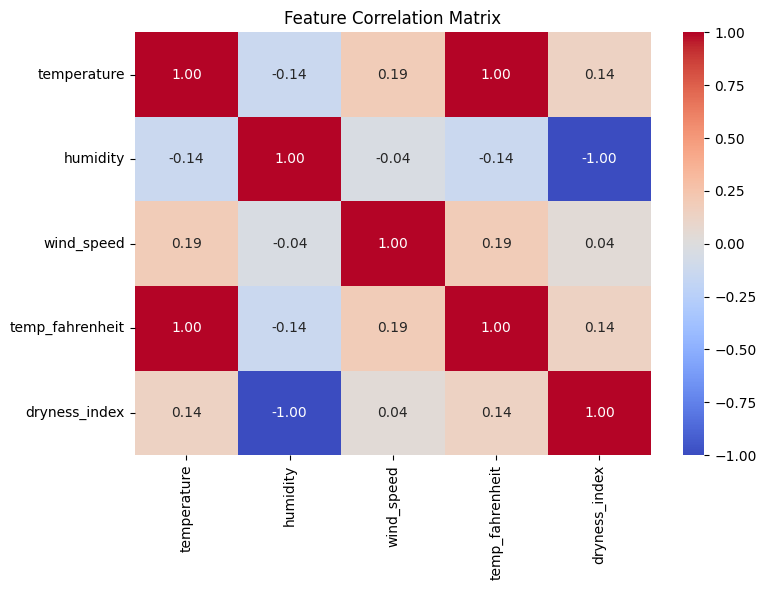

In [111]:
# Create a sample DataFrame with some correlated features
np.random.seed(42)
data = {
    "temperature": np.random.normal(20, 5, 100),
    "humidity": np.random.normal(60, 10, 100),
    "wind_speed": np.random.normal(15, 5, 100),
}
df = pd.DataFrame(data)

# Engineer a new feature highly correlated with temperature
df["temp_fahrenheit"] = df["temperature"] * 1.8 + 32

# Engineer a new feature negatively correlated with humidity
df["dryness_index"] = 100 - df["humidity"]

# Visualise the correlation matrix
correlation_matrix = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## The Rationale for Removing Redundancy

A lean, informative feature set is often more powerful than a large, noisy one. Redundant features introduce two primary problems into the modeling process:

1.  **Multicollinearity**: This is a statistical issue that occurs when two or more predictor features in a model are highly correlated. In linear models (like Linear or Logistic Regression), multicollinearity makes it difficult for the model to estimate the independent effect of each correlated feature on the outcome. This can lead to unstable coefficient estimates and a model that is difficult to interpret. By removing one of the correlated features, you clarify the model and stabilise its results.
2.  **Model Complexity and Overfitting**: Each feature adds a dimension to the dataset. Unnecessary features add complexity without providing new information, increasing the risk that the model will learn from random noise in the training data (**overfitting**) rather than the true underlying signal. A simpler model with fewer features is often more generalisable to new, unseen data.

Feature selection is an iterative process; you may remove features and test your model's performance, potentially re-evaluating your choices if performance does not improve.

### Identifying and Removing Logically Redundant Features

This form of feature selection relies heavily on **domain knowledge** and a common-sense understanding of what the features represent. You manually inspect the feature set to identify columns that provide the same or very similar information.

Common scenarios include:

  - **Geographical Data**: A dataset with columns for `city`, `state`, `postcode`, `latitude`, and `longitude` contains overlapping information. For a model predicting regional trends, `state` might be sufficient. For a distance-based model, `latitude` and `longitude` are essential, making the others redundant.
  - **Post-Feature Engineering**: After creating new features, the original features used to create them may become redundant. For example, after extracting the month and year from a `datetime` column, the original, granular `datetime` column might be dropped.



In [112]:
# Sample data with logically redundant features
data = {
    "city": ["hico", "mackinaw city", "winchester"],
    "state": ["tx", "mi", "ky"],
    "lat": [31.98, 45.78, 37.99],
    "long": [-98.03, -84.72, -84.18],
}
locations_df = pd.DataFrame(data)
print("Original DataFrame:")
display(locations_df)

# For a distance-based model, lat/long are crucial. City/state are redundant.
features_to_drop = ["city", "state"]
locations_df_reduced = locations_df.drop(columns=features_to_drop)

print("DataFrame after Dropping Redundant Features:")
display(locations_df_reduced)

Original DataFrame:


,city,state,lat,long
0,hico,tx,31.98,-98.03
1,mackinaw city,mi,45.78,-84.72
2,winchester,ky,37.99,-84.18


DataFrame after Dropping Redundant Features:


,lat,long
0,31.98,-98.03
1,45.78,-84.72
2,37.99,-84.18


## Identifying and Removing Statistically Correlated Features

This is a data-driven approach to finding redundancy. We use a statistical measure, the **Pearson correlation coefficient**, to identify features that have a strong linear relationship. This coefficient, $r$, ranges from -1 to +1:

  - **+1**: Perfect positive correlation (as one feature increases, the other increases proportionally).
  - **-1**: Perfect negative correlation (as one feature increases, the other decreases proportionally).
  - **0**: No linear correlation.

The formula for the Pearson correlation coefficient between two features, $x$ and $y$, is:
$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

A common practice is to calculate the pairwise correlation of all features and then systematically remove one feature from any pair with a correlation above a certain absolute threshold (e.g., 0.8).

### A Practical Workflow for Removing Correlated Features

This workflow shows how to automatically identify and remove highly correlated features.

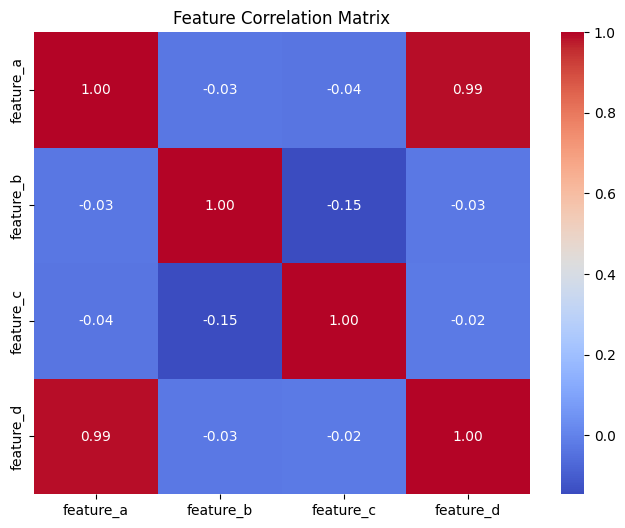

Original columns: ['feature_a', 'feature_b', 'feature_c', 'feature_d']
Columns to drop: ['feature_d']
Remaining columns after removal: ['feature_a', 'feature_b', 'feature_c']


In [113]:
# 1. Create a sample DataFrame with correlated features
np.random.seed(42)
data = {
    "feature_a": np.random.rand(100),
    "feature_b": np.random.rand(100) * 50,
    "feature_c": np.random.rand(100) - 20,
}
correlated_df = pd.DataFrame(data)
# Create a feature highly correlated with 'feature_a'
correlated_df["feature_d"] = correlated_df["feature_a"] * 2 + np.random.normal(
    0, 0.1, 100
)

# 2. Calculate and visualise the correlation matrix
correlation_matrix = correlated_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.show()

# 3. Automatically identify and remove one of each highly correlated pair
# Define the correlation threshold
corr_threshold = 0.8

# Create a set to hold the names of columns to drop
columns_to_drop = set()

# Iterate over the upper triangle of the correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        # If the absolute correlation is above the threshold
        if abs(correlation_matrix.iloc[i, j]) > corr_threshold:
            # Get the name of the column to drop
            colname = correlation_matrix.columns[i]
            columns_to_drop.add(colname)

# 4. Drop the identified columns
df_uncorrelated = correlated_df.drop(columns=list(columns_to_drop))

print("Original columns:", correlated_df.columns.tolist())
print("Columns to drop:", list(columns_to_drop))
print("Remaining columns after removal:", df_uncorrelated.columns.tolist())

The heatmap immediately shows the strong positive correlation (`0.98`) between `feature_a` and `feature_d`. The automated script identifies this pair and flags `feature_d` for removal, resulting in a cleaner, less redundant feature set for modeling.

In [114]:
volunteer.head()

,opportunity_id,content_id,vol_requests,event_time,title,hits,summary,is_priority,category_id,category_desc,...,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA,start_date_converted,start_date_month
1,5008,37036,2,0,Web designer,22,Build a website for an Afghan business,NaN,1.0,Strengthening Communities,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-02-01,2
2,5016,37143,20,0,Urban Adventures - Ice Skating at Lasker Rink,62,Please join us and the students from Mott Hall...,NaN,1.0,Strengthening Communities,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-29,1
3,5022,37237,500,0,Fight global hunger and support women farmers ...,14,The Oxfam Action Corps is a group of dedicated...,NaN,1.0,Strengthening Communities,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-02-14,2
4,5055,37425,15,0,Stop 'N' Swap,31,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-02-05,2
5,5056,37426,15,0,Queens Stop 'N' Swap,135,Stop 'N' Swap reduces NYC's waste by finding n...,NaN,4.0,Environment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-02-12,2
